In [24]:
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential # Builds the layers one by one
from tensorflow.keras.layers import Dense #creates a fully connected layer
import numpy as np

In [25]:
texts = [
    "I love Basketball",
    "I love to watch Sports",
    "I love to play basketball with my friends",
    "Cricket is an amazing sport",
    "Football is exciting to watch",
    "I enjoy playing badminton",

    "I hate Tennis",
    "I think cricket is worst",
    "It was worst game",
    "Basketball is boring",
    "I dislike football matches",
    "Tennis was terrible",

    "Basketball is okay",
    "Cricket is average",
    "Football is neither good nor bad",
    "I love and hate Basketball",
    "Some sports are good and some are bad",
    "The game was fine",

    "I love and hate cricket",
    "I like and dislike football",
    "Cricket was good and bad",
    "The match had both good and bad moments",
    "I enjoyed some parts but hated some parts",
    "Basketball was neither good nor bad"
]


In [26]:
labels = np.array([
    2,2,2,2,2,2,
    0,0,0,0,0,0,
    1,1,1,1,1,1,
    1,1,1,1,1,1
])

In [ ]:
vectorizer=TfidfVectorizer()             #TF-IDF 

In [28]:
X=vectorizer.fit_transform(texts).toarray()
print("Vocabulary")
print(vectorizer.get_feature_names_out())
print("\nTF-IDF Numeric representation:")
print(X)


Vocabulary
['amazing' 'an' 'and' 'are' 'average' 'bad' 'badminton' 'basketball'
 'boring' 'both' 'but' 'cricket' 'dislike' 'enjoy' 'enjoyed' 'exciting'
 'fine' 'football' 'friends' 'game' 'good' 'had' 'hate' 'hated' 'is' 'it'
 'like' 'love' 'match' 'matches' 'moments' 'my' 'neither' 'nor' 'okay'
 'parts' 'play' 'playing' 'some' 'sport' 'sports' 'tennis' 'terrible'
 'the' 'think' 'to' 'was' 'watch' 'with' 'worst']

TF-IDF Numeric representation:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.540015   0.         0.        ]
 [0.         0.         0.         ... 0.         0.42505249 0.        ]
 ...
 [0.         0.         0.26003127 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [29]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(X, labels, epochs=100, verbose=0)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,347 (9.17 KB)

 Trainable params: 2,347 (9.17 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
new_text = ["I hate and love cricket"]

new_vector = vectorizer.transform(new_text).toarray()

prediction = model.predict(new_vector)

print("\nProbabilities:", prediction[0])

predicted_class = np.argmax(prediction)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

Probabilities: [0.3110834  0.3805221  0.30839452]
Neutral Review


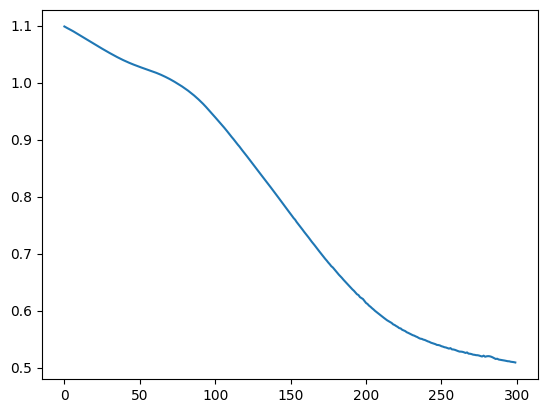

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


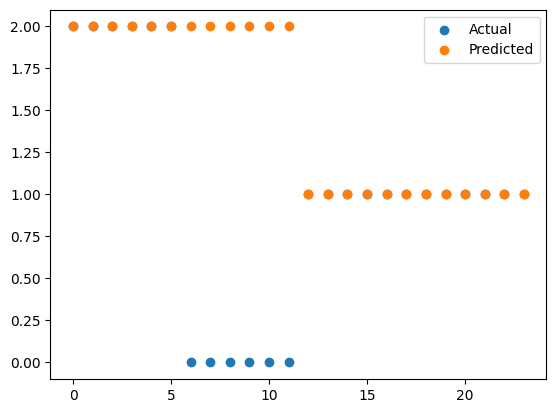

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.show()


predicted_classes = np.argmax(model.predict(X), axis=1)

plt.scatter(range(len(labels)), labels, label="Actual")
plt.scatter(range(len(predicted_classes)), predicted_classes, label="Predicted")
plt.legend()
plt.show()

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

In [35]:
vectorizer = CountVectorizer()

X1= vectorizer.fit_transform(texts).toarray()

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nNumeric representation:")
print(X1)

Vocabulary:
['amazing' 'an' 'and' 'are' 'average' 'bad' 'badminton' 'basketball'
 'boring' 'both' 'but' 'cricket' 'dislike' 'enjoy' 'enjoyed' 'exciting'
 'fine' 'football' 'friends' 'game' 'good' 'had' 'hate' 'hated' 'is' 'it'
 'like' 'love' 'match' 'matches' 'moments' 'my' 'neither' 'nor' 'okay'
 'parts' 'play' 'playing' 'some' 'sport' 'sports' 'tennis' 'terrible'
 'the' 'think' 'to' 'was' 'watch' 'with' 'worst']

Numeric representation:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 ...
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [36]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X1.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(X1, labels, epochs=100, verbose=0)

new_text1 = ["I hate and love watching TV"]

new_vector1 = vectorizer.transform(new_text1).toarray()

prediction1 = model.predict(new_vector1)

print("\nProbabilities:", prediction1[0])

predicted_class = np.argmax(prediction1)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

d:\Data Analysis\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,347 (9.17 KB)

 Trainable params: 2,347 (9.17 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

Probabilities: [0.01078991 0.8173     0.17191009]
Neutral Review


In [37]:
from gensim.models import FastText

In [38]:
tokenized_texts = [sentence.lower().split() for sentence in texts]

# Train FastText model
fasttext_model = FastText(
    sentences=tokenized_texts,
    vector_size=20,
    window=3,
    min_count=1,
    epochs=100
)

X = []

for sentence in tokenized_texts:
    word_vectors = []
    for word in sentence:
        word_vectors.append(fasttext_model.wv[word])
    
    sentence_vector = np.mean(word_vectors, axis=0)
    X.append(sentence_vector)

X = np.array(X)

print("FastText Numeric Representation:")
print(X)

FastText Numeric Representation:
[[-2.91427854e-03  1.08936429e-03  5.98190166e-03  7.20881671e-03
  -2.13834960e-02 -2.01924406e-02  2.20368225e-02  2.38845851e-02
  -8.81291088e-03  3.08358553e-03  8.87867436e-03 -3.14079202e-03
   5.43490192e-03  1.86599251e-02  2.31702509e-03 -2.49026413e-03
   1.79701429e-02  2.12456076e-03 -2.08130311e-02 -1.26641514e-02]
 [-7.29595358e-03  6.27692882e-03  1.50337315e-03  4.87820990e-03
  -1.18773486e-02 -1.38455536e-02  1.32163167e-02  1.77641995e-02
  -5.25161298e-03  1.90514326e-03  1.12787811e-02  5.30662131e-04
   1.14692864e-03  1.66561492e-02  1.44880521e-03 -7.94256222e-04
   2.22250149e-02 -8.70525837e-03 -1.75918974e-02 -6.95434585e-03]
 [ 2.18430255e-03  6.42737281e-03  5.02962153e-03  3.51186120e-03
  -1.27148256e-02 -1.73097905e-02  8.19936674e-03  8.75238143e-03
  -6.50422275e-03  2.09376123e-03  5.48715796e-03  2.19545327e-05
  -2.20759097e-03  8.13811552e-03  7.77590962e-04  7.57707050e-04
   1.46399941e-02 -2.35592015e-03 -1.2977

In [39]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(X, labels, epochs=300, verbose=0)


new_text = ["I love and hate cricket"]

tokenized_new_text = [new_text[0].lower().split()]

new_X = []

for sentence in tokenized_new_text:
    word_vectors = []
    for word in sentence:
        word_vectors.append(fasttext_model.wv[word])
    
    sentence_vector = np.mean(word_vectors, axis=0)
    new_X.append(sentence_vector)

new_X = np.array(new_X)

prediction = model.predict(new_X)

print("\nProbabilities:", prediction[0])

predicted_class = np.argmax(prediction)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387 (5.42 KB)

 Trainable params: 1,387 (5.42 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

Probabilities: [0.30185714 0.68705827 0.01108449]
Neutral Review


In [41]:
from gensim.models import Word2Vec



tokenized_texts = [sentence.lower().split() for sentence in texts]


wordvec= Word2Vec(
    sentences=tokenized_texts,
    vector_size=20,
    window=3,
    min_count=1,
    workers=4
)

X = []

for sentence in tokenized_texts:

    word_vectors = []

    for word in sentence:
        word_vectors.append(wordvec.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)

    X.append(sentence_vector)

X = np.array(X)

print("Word Embedding Representation:")
print(X)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


history = model.fit(
    X,
    labels,
    epochs=300,
    verbose=0
)

new_text = ["I love and hate cricket"]

tokenized_new = [new_text[0].lower().split()]

new_X = []

for sentence in tokenized_new:

    word_vectors = []

    for word in sentence:
        word_vectors.append(glove_model.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)

    new_X.append(sentence_vector)

new_X = np.array(new_X)


prediction = model.predict(new_X)

print("\nProbabilities:", prediction[0])

predicted_class = np.argmax(prediction)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

Word Embedding Representation:
[[-1.77554823e-02  6.28314214e-03 -6.08298928e-03 -6.27622753e-03
  -1.20187225e-02  1.17467588e-03  2.22643018e-02  1.46309463e-02
  -5.70047938e-04  8.48015584e-03  1.52439214e-02 -3.22071346e-03
  -9.14103177e-04  6.38643885e-03 -2.08713114e-03 -1.32525889e-02
   5.43018291e-03 -3.90014495e-03 -9.64858383e-03 -3.64848264e-02]
 [-8.02702922e-03 -7.82197155e-03 -7.61388848e-03  2.04944052e-02
   1.09176082e-03 -5.13618207e-03  2.90486123e-02  9.90149006e-03
  -1.67328678e-03  3.75406514e-03  3.51978326e-03 -2.64000148e-03
   6.99342054e-04  4.20674589e-03 -1.31264422e-02 -1.48734879e-02
  -1.81075521e-02 -6.15548482e-03 -3.04597942e-03 -3.29043269e-02]
 [-2.46135611e-03  9.45046172e-03  4.89481119e-03 -3.13210813e-03
  -9.63764545e-03 -5.90270385e-03 -3.21975886e-03  5.48996637e-03
   2.15075817e-03  3.00844689e-03  9.46692098e-03  8.74772668e-03
  -2.63834023e-04 -1.83468265e-03  5.34824282e-03 -1.93695407e-02
  -4.16012993e-03 -6.18736260e-03  7.477514

d:\Data Analysis\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387 (5.42 KB)

 Trainable params: 1,387 (5.42 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

Probabilities: [0.01335478 0.9830414  0.00360375]
Neutral Review


In [47]:
##FastText produced better probabilities because the Neutral class received the highest confidence score (68.7%) while the Positive class received a very low score (1.1%), showing that the model understood the mixed sentiment more accurately.